In [1]:
import pandas as pd
import numpy as np
import pyodbc
import warnings
from scipy.stats import linregress
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.min_rows', 50)

def run_sql(query):
    with pyodbc.connect("DSN=Redshift_prod_new") as conn:
        warnings.filterwarnings("ignore", category=UserWarning)
        df = pd.read_sql_query(sql=query, con=conn)
        warnings.filterwarnings("default", category=UserWarning)
    return df

with pyodbc.connect("DSN=Redshift_prod_new") as conn:
    conn.cursor().execute("SELECT 1").fetchone()
print("ODBC connection OK")

ODBC connection OK


In [2]:
loan_df = run_sql("""
    SELECT
        cd.account_number,
        dru.riskdealergroup AS lob,
        cd.book_date,
        CASE
            WHEN cd.cb_vantage_score IS NULL THEN cd.pb_vantage_score
            ELSE (cd.pb_vantage_score + cd.cb_vantage_score) / 2.0
        END AS vantage
    FROM edwnpi.los_deal_current_fact cd
    LEFT JOIN edwnpi.dealer_rollup_scd_current dru
        ON dru.dealer_number = cd.dealer_number
    WHERE cd.book_date >= '2022-04-01'
      AND cd.book_date <= '2024-12-31'
      AND cd.data_source_name != 'SPARTAN'
      AND dru.riskdealergroup NOT IN ('STE', 'MCY', 'ORL')
""")

loan_df['book_date'] = pd.to_datetime(loan_df['book_date'])
print(f"Rows: {len(loan_df):,}")
print(f"Book date range: {loan_df['book_date'].min()} to {loan_df['book_date'].max()}")
print(f"\nLOB distribution:")
print(loan_df['lob'].value_counts())
print(f"\nVantage score summary:")
print(loan_df['vantage'].describe().round(1))

Rows: 282,369
Book date range: 2022-04-01 00:00:00 to 2024-12-31 00:00:00

LOB distribution:
lob
KMX    145125
FRN     43946
ENT     41176
STG     25502
AN      17253
FLD      9367
Name: count, dtype: int64

Vantage score summary:
count    249954.0
mean        562.3
std          57.1
min         314.0
25%         525.0
50%         557.0
75%         596.0
max         846.0
Name: vantage, dtype: float64


In [3]:
actuals_df = run_sql("""
    WITH all_accounts AS (
        SELECT account_number,
               sp_book_date_quarter_vintage,
               MAX(proceeds) AS proceeds
        FROM edwnpi.svc_master_monthend
        WHERE sp_book_date_quarter_vintage >= '2022 Q2'
        GROUP BY 1, 2
    ),
    chargeoffs AS (
        SELECT account_number,
               sp_book_date_quarter_vintage,
               MAX(gross_loss_amt) AS gross_loss_amt
        FROM edwnpi.svc_master_monthend
        WHERE sp_book_date_quarter_vintage >= '2022 Q2'
          AND account_life_cycle = 'CHARGEOFF'
        GROUP BY 1, 2
    )
    SELECT a.account_number,
           a.sp_book_date_quarter_vintage AS vintage,
           a.proceeds,
           COALESCE(co.gross_loss_amt, 0) AS gross_loss_amt,
           CASE WHEN co.account_number IS NOT NULL THEN 1 ELSE 0 END AS is_chargeoff
    FROM all_accounts a
    LEFT JOIN chargeoffs co
        ON a.account_number = co.account_number
       AND a.sp_book_date_quarter_vintage = co.sp_book_date_quarter_vintage
""")

print(f"Actuals rows: {len(actuals_df):,}")
print(f"Chargeoff rate: {actuals_df['is_chargeoff'].mean():.4f}")
print(f"Vintages: {actuals_df['vintage'].nunique()}")
print(f"Vintage range: {actuals_df['vintage'].min()} to {actuals_df['vintage'].max()}")

Actuals rows: 607,425
Chargeoff rate: 0.2470
Vintages: 18
Vintage range: 2022 Q2 to 225 Q4


In [4]:
merged = loan_df.merge(
    actuals_df[['account_number', 'vintage', 'proceeds', 'gross_loss_amt']],
    on='account_number', how='inner'
)
print(f"Merged rows: {len(merged):,}")

merged['gross_loss_pct'] = merged['gross_loss_amt'] / merged['proceeds']

VANTAGE_MIN, VANTAGE_MAX, BAND_WIDTH = 400, 700, 5
vantage_bins = list(range(VANTAGE_MIN, VANTAGE_MAX + BAND_WIDTH, BAND_WIDTH))
vantage_labels = [f"{b}-{b + BAND_WIDTH}" for b in vantage_bins[:-1]]
merged['vantage_band'] = pd.cut(merged['vantage'], bins=vantage_bins, labels=vantage_labels, right=True)

merged['segment'] = np.where(merged['lob'] == 'KMX', 'KMX', 'Non-KMX')

in_range = merged['vantage_band'].notna()
print(f"Accounts in vantage range ({VANTAGE_MIN}-{VANTAGE_MAX}): {in_range.sum():,} / {len(merged):,} ({in_range.mean():.1%})")
print(f"\nSegment counts (in range):")
print(merged.loc[in_range, 'segment'].value_counts())
print(f"\nLOBs in Non-KMX segment:")
print(merged.loc[in_range & (merged['segment'] == 'Non-KMX'), 'lob'].value_counts().sort_index())

Merged rows: 282,356
Accounts in vantage range (400-700): 245,051 / 282,356 (86.8%)

Segment counts (in range):
segment
KMX        128032
Non-KMX    117019
Name: count, dtype: int64

LOBs in Non-KMX segment:
lob
AN     14735
ENT    36415
FLD     7993
FRN    36333
STG    21543
Name: count, dtype: int64


In [5]:
for seg in ['KMX', 'Non-KMX']:
    seg_df = merged[(merged['segment'] == seg) & merged['vantage_band'].notna()]
    print(f"\n{'=' * 70}")
    print(f"DISTRIBUTION SUMMARY -- {seg} (N={len(seg_df):,})")
    print(f"{'=' * 70}")
    print(f"\nVantage score:")
    print(seg_df['vantage'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(1))
    print(f"\nGross loss rate: {seg_df['gross_loss_pct'].mean():.4f}")
    print(f"Chargeoff count: {(seg_df['gross_loss_amt'] > 0).sum():,} / {len(seg_df):,}")


DISTRIBUTION SUMMARY -- KMX (N=128,032)

Vantage score:
count    128032.0
mean        559.5
std          51.1
min         401.0
10%         497.0
25%         525.0
50%         556.0
75%         591.5
90%         627.0
max         700.0
Name: vantage, dtype: float64

Gross loss rate: 0.3276
Chargeoff count: 49,339 / 128,032

DISTRIBUTION SUMMARY -- Non-KMX (N=117,019)

Vantage score:
count    117019.0
mean        559.5
std          54.3
min         401.0
10%         493.0
25%         523.0
50%         556.0
75%         595.0
90%         633.0
max         700.0
Name: vantage, dtype: float64

Gross loss rate: 0.3528
Chargeoff count: 48,017 / 117,019


In [6]:
def build_gl_by_vantage(df, segment_label):
    """Aggregate GL rate per 5-point vantage band."""
    grouped = df.groupby('vantage_band', observed=True).agg(
        total_gl=('gross_loss_amt', 'sum'),
        total_proceeds=('proceeds', 'sum'),
        loan_count=('account_number', 'count'),
        avg_vantage=('vantage', 'mean')
    ).reset_index()
    grouped['gl_rate'] = grouped['total_gl'] / grouped['total_proceeds']
    grouped['gl_rate_pct'] = grouped['gl_rate'] * 100

    print(f"\n{'=' * 80}")
    print(f"GROSS LOSS RATE BY VANTAGE BAND -- {segment_label}")
    print(f"{'=' * 80}")
    display(grouped[['vantage_band', 'loan_count', 'avg_vantage', 'gl_rate_pct']].round(3))
    return grouped

kmx_df = merged[(merged['segment'] == 'KMX') & merged['vantage_band'].notna()].copy()
kmx_gl = build_gl_by_vantage(kmx_df, 'KMX')


GROSS LOSS RATE BY VANTAGE BAND -- KMX


,vantage_band,loan_count,avg_vantage,gl_rate_pct
0,400-405,36,402.833,36.211
1,405-410,44,408.114,30.634
2,410-415,73,413.425,40.122
3,415-420,94,418.356,33.436
4,420-425,117,423.090,34.356
5,425-430,176,428.031,40.135
6,430-435,193,432.984,40.186
7,435-440,240,438.135,31.205
8,440-445,312,443.157,37.782
9,445-450,403,447.938,38.595


In [7]:
nonkmx_df = merged[(merged['segment'] == 'Non-KMX') & merged['vantage_band'].notna()].copy()
nonkmx_gl = build_gl_by_vantage(nonkmx_df, 'Non-KMX (excl STE, MCY, ORL)')


GROSS LOSS RATE BY VANTAGE BAND -- Non-KMX (excl STE, MCY, ORL)


,vantage_band,loan_count,avg_vantage,gl_rate_pct
0,400-405,42,402.976,32.743
1,405-410,74,407.838,48.918
2,410-415,87,412.787,51.176
3,415-420,123,417.894,49.568
4,420-425,127,422.894,44.634
5,425-430,181,428.163,44.895
6,430-435,224,432.924,43.396
7,435-440,310,438.077,48.490
8,440-445,384,443.007,42.069
9,445-450,499,447.912,41.636


In [8]:
MIN_BAND_COUNT = 30

def compute_slope(grouped_df, segment_label):
    """Linear regression of GL rate on vantage band midpoint."""
    valid = grouped_df[grouped_df['loan_count'] >= MIN_BAND_COUNT].copy()
    if len(valid) < 3:
        print(f"{segment_label}: insufficient bands with >= {MIN_BAND_COUNT} loans")
        return None

    x = valid['avg_vantage'].values
    y = valid['gl_rate'].values

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    print(f"\n{'=' * 80}")
    print(f"SLOPE ANALYSIS -- {segment_label}")
    print(f"{'=' * 80}")
    print(f"Bands used:          {len(valid)} (of {len(grouped_df)}, min {MIN_BAND_COUNT} loans per band)")
    print(f"Vantage range:       {x.min():.1f} to {x.max():.1f}")
    print(f"Slope per point:     {slope:+.6f} ({slope * 100:+.4f} pp per vantage point)")
    print(f"Intercept:           {intercept:.6f}")
    print(f"R-squared:           {r_value**2:.4f}")
    print(f"p-value:             {p_value:.2e}")
    print(f"Std error:           {std_err:.6f}")
    print(f"\nInterpretation: Each +1 vantage point is associated with a")
    print(f"  {slope * 100:+.4f} percentage point change in gross loss rate.")
    print(f"  Over a 50-point span: {slope * 50 * 100:+.2f} pp change.")

    return {'segment': segment_label, 'slope': slope, 'intercept': intercept,
            'r_squared': r_value**2, 'p_value': p_value, 'std_err': std_err,
            'n_bands': len(valid), 'x': x, 'y': y}

kmx_result = compute_slope(kmx_gl, 'KMX')
nonkmx_result = compute_slope(nonkmx_gl, 'Non-KMX (excl STE, MCY, ORL)')

summary_rows = []
for r in [kmx_result, nonkmx_result]:
    if r:
        summary_rows.append({
            'Segment': r['segment'],
            'Slope (per point)': f"{r['slope']:+.6f}",
            'Slope (pp per point)': f"{r['slope'] * 100:+.4f}",
            'R-squared': f"{r['r_squared']:.4f}",
            'p-value': f"{r['p_value']:.2e}",
            'Bands': r['n_bands']
        })

print(f"\n{'=' * 80}")
print("SLOPE COMPARISON SUMMARY")
print(f"{'=' * 80}")
display(pd.DataFrame(summary_rows))


SLOPE ANALYSIS -- KMX
Bands used:          60 (of 60, min 30 loans per band)
Vantage range:       402.8 to 698.2
Slope per point:     -0.000405 (-0.0405 pp per vantage point)
Intercept:           0.542623
R-squared:           0.7123
p-value:             2.50e-17
Std error:           0.000034

Interpretation: Each +1 vantage point is associated with a
  -0.0405 percentage point change in gross loss rate.
  Over a 50-point span: -2.02 pp change.

SLOPE ANALYSIS -- Non-KMX (excl STE, MCY, ORL)
Bands used:          60 (of 60, min 30 loans per band)
Vantage range:       403.0 to 698.0
Slope per point:     -0.000746 (-0.0746 pp per vantage point)
Intercept:           0.769492
R-squared:           0.8618
p-value:             1.34e-26
Std error:           0.000039

Interpretation: Each +1 vantage point is associated with a
  -0.0746 percentage point change in gross loss rate.
  Over a 50-point span: -3.73 pp change.

SLOPE COMPARISON SUMMARY


,Segment,Slope (per point),Slope (pp per point),R-squared,p-value,Bands
0,KMX,-0.000405,-0.0405,0.7123,2.50e-17,60
1,"Non-KMX (excl STE, MCY, ORL)",-0.000746,-0.0746,0.8618,1.34e-26,60


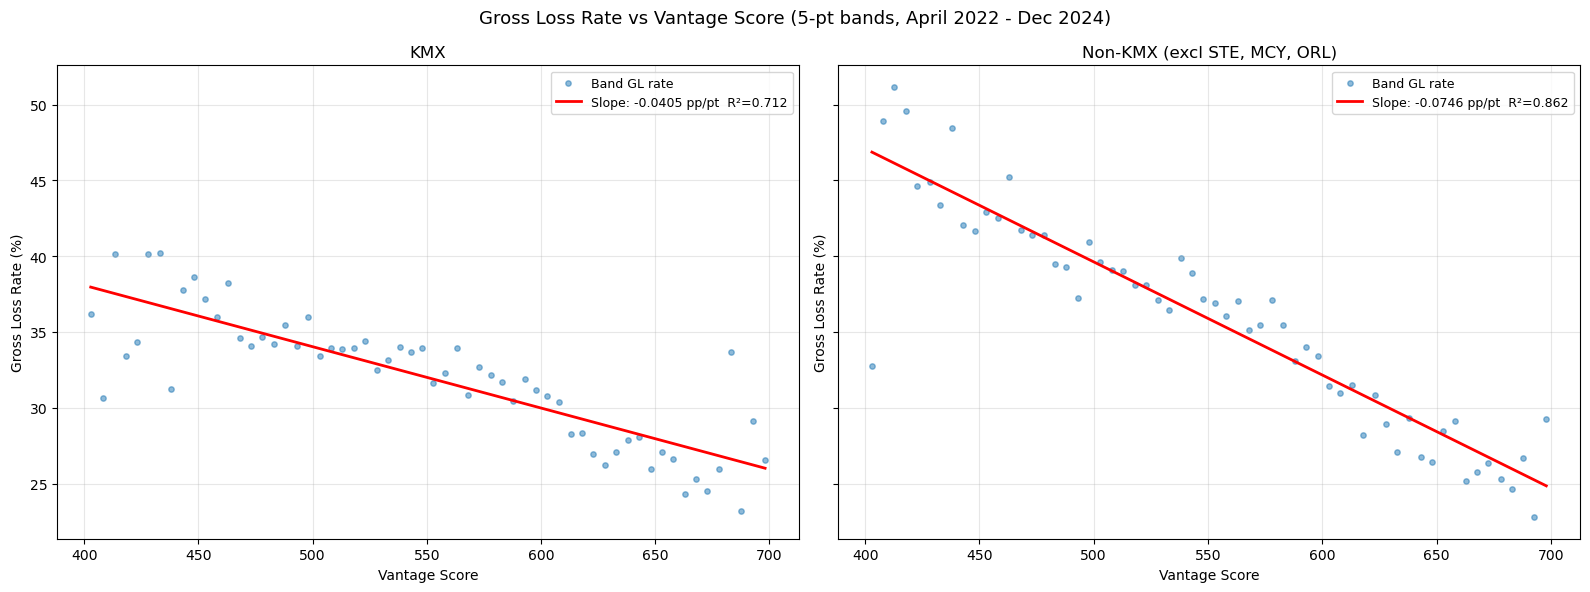

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, result, gl_df, title in [
    (axes[0], kmx_result, kmx_gl, 'KMX'),
    (axes[1], nonkmx_result, nonkmx_gl, 'Non-KMX (excl STE, MCY, ORL)')
]:
    if result is None:
        ax.set_title(f"{title} -- insufficient data")
        continue

    x, y = result['x'], result['y']
    ax.scatter(x, y * 100, alpha=0.5, s=15, label='Band GL rate')

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = (result['slope'] * x_line + result['intercept']) * 100
    ax.plot(x_line, y_line, color='red', linewidth=2,
            label=f"Slope: {result['slope'] * 100:+.4f} pp/pt  R²={result['r_squared']:.3f}")

    ax.set_xlabel('Vantage Score')
    ax.set_ylabel('Gross Loss Rate (%)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Gross Loss Rate vs Vantage Score (5-pt bands, April 2022 - Dec 2024)', fontsize=13)
plt.tight_layout()
plt.show()